<a href="https://colab.research.google.com/github/Santiago-Parada/Public-Projects/blob/main/Credit_Default_(XGBoost).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: center;">

<h1 style="font-size: 3em; margin-bottom: 0.2em;">Credit Default</h1>

<h3 style="margin-top: 0; margin-bottom: 1em;">Santiago Pérez Parada</h3>


</div>




Objetivo: Predecir la probabilidad de incumplimiento de una cartear de clientes en un tiempo dado. Para este se realizará un proceso de feature selection, que nos asegura predictibilidad y estabilidad de las variables, y una hiperparametrización para buscar el mejor ajuste en un XGBost (Extreme Gradient Boosting).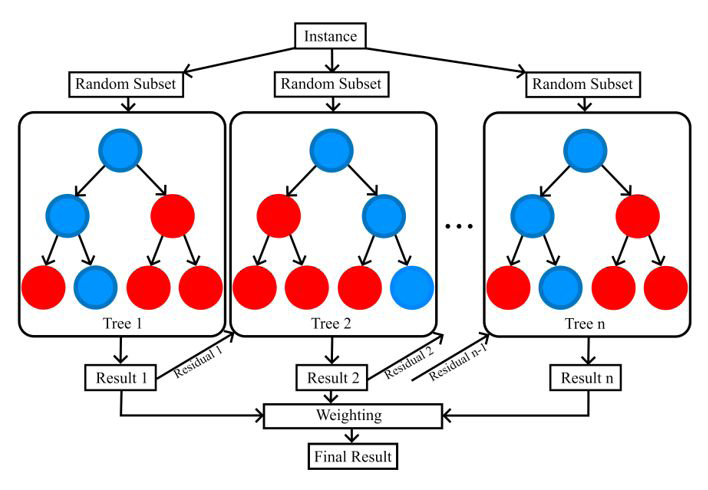

# Importar información

In [1]:

import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.inspection import PartialDependenceDisplay
from scipy.stats import ks_2samp
from IPython.display import Latex
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from warnings import filterwarnings

filterwarnings("ignore")


# ============================================================
# ESPACIO DE PARÁMETROS
# SOLO SE USARÁN ESTOS VALORES
# ============================================================
ts=0.3
rs=1234
iv=0.1
csi_th=0.1
cor=0.9
n_splits=5
eval_metric="logloss"
# Número de iteraciones aleatorias
n_iter = 64
param_grid = {
    'max_depth': [3,8],
    'learning_rate': [0.05, 0.125],
    'n_estimators': [50,200],
    'min_child_weight': [1,100],
    'colsample_bytree': [1],
    'subsample': [1]
}

# data = fetch_openml(data_id=45016, as_frame=True)
data = fetch_openml(data_id=45014, as_frame=True)
X = data.data
y = data.target


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=ts, stratify=y, random_state=rs
)

In [3]:
Markdown(fr"""# Information Value
Descripicion: Calculamos el information value (estadístico de predictibilidad de las características) quedándonos solo con las que tienen un IV mayor del {iv*100}%""")

# Information Value
Descripicion: Calculamos el information value (estadístico de predictibilidad de las características) quedándonos solo con las que tienen un IV mayor del 10.0%

In [4]:

def iv_and_woe(X, y, bins=10):

    data = pd.concat([X, y], axis=1)
    data.columns = [X.name, y.name]

    # Binarizar la variable si es numérica
    if np.issubdtype(X.dtype, np.number):
        data['bin'] = pd.qcut(data[X.name], bins, duplicates='drop')
    else:
        data['bin'] = data[X.name]

    # Calcular los eventos y no eventos por bin
    grouped = data.groupby('bin').agg({y.name: ['count', 'sum']})
    grouped.columns = ['total', 'good']
    grouped['bad'] = grouped['total'] - grouped['good']
    grouped['good_dist'] = grouped['good'] / grouped['good'].sum()
    grouped['bad_dist'] = grouped['bad'] / grouped['bad'].sum()
    grouped['woe'] = np.log(grouped['good_dist'] / grouped['bad_dist'])
    grouped['iv'] = (grouped['good_dist'] - grouped['bad_dist']) * grouped['woe']

    # Calcular el IV total
    iv_total = grouped['iv'].sum()
    return {'Variable': X.name, 'IV': iv_total}, grouped[['woe']]

iv_list = []
woe_list = []
for k in X.columns:
  i,j=iv_and_woe(X_train[k], y_train, bins=10)
  iv_list.append(i)
  woe_list.append(j)

iv_df = pd.DataFrame(iv_list)
iv_df = iv_df.sort_values(by='IV', ascending=False)

woe_df = pd.concat(woe_list, axis=1)
woe_df.columns = iv_df['Variable']
iv_df=iv_df[iv_df["IV"]>iv]



In [5]:
iv_df=iv_df[iv_df["IV"]>iv]
print("Variables seleccionadas")
iv_df



Variables seleccionadas


,Variable,IV
21,V22,0.615142
1,V2,0.538787
5,V6,0.522162
19,V20,0.520090
14,V15,0.492739
22,V23,0.471454
13,V14,0.445994
11,V12,0.400554
12,V13,0.385204
0,V1,0.302054


In [6]:
col_list = iv_df['Variable'].dropna().unique().tolist()
X=X[col_list]
X_train=X_train[col_list]
X_test=X_test[col_list]



In [7]:
Markdown(fr"""# CSI
Descripcion: Calculamos el Caracthericstic Stability Index (estadístico de estabilidad para características) quedándonos con las menores a {csi_th*100}%
""")

# CSI
Descripcion: Calculamos el Caracthericstic Stability Index (estadístico de estabilidad para características) quedándonos con las menores a 10.0%


In [8]:
def psi(expected_series, actual_series, n_bins=10):

    # Handle numerical variables
    # Use pd.qcut to create bins for numerical data
    if len(expected_series.unique())>2:
      bins = pd.qcut(expected_series, q=n_bins, duplicates='drop', retbins=True)[1]
      expected_binned = pd.cut(expected_series, bins=bins, include_lowest=True)
      actual_binned = pd.cut(actual_series, bins=bins, include_lowest=True)

      expected_dist = expected_binned.value_counts(normalize=True).sort_index()
      actual_dist = actual_binned.value_counts(normalize=True).sort_index()
    else:
      expected_dist = expected_series.value_counts(normalize=True).sort_index()
      actual_dist = actual_series.value_counts(normalize=True).sort_index()
    # Add a small epsilon to avoid division by zero or log(0)
    epsilon = 0.00000001
    expected_dist = expected_dist.replace(0, epsilon)
    actual_dist = actual_dist.replace(0, epsilon)

    psi = ((expected_dist - actual_dist) * np.log(expected_dist / actual_dist)).sum()
    return psi
df=[]
for i in X.columns:
  df.append([i,psi(X_train[i],X_test[i])])

csi=pd.DataFrame(df,columns=["variable","csi"])




In [9]:

csi=csi[csi["csi"]<csi_th]
col_list = csi['variable'].dropna().unique().tolist()
print("Variables seleccionadas")
csi


Variables seleccionadas


,variable,csi
0,V22,0.001075
1,V2,0.000825
2,V6,0.000658
3,V20,0.001539
4,V15,0.000743
5,V23,0.001567
6,V14,0.000846
7,V12,0.001042
8,V13,0.001334
9,V1,0.000937


In [10]:
X=X[col_list]
X_train=X_train[col_list]
X_test=X_test[col_list]

In [11]:
Markdown(fr"""# Matriz de correlación
Obtenemos las correlaciones entre características, quitando aquellas que son mayores al {cor*100}%, de tal manera que se conserva la que tiene mayor IV
""")

# Matriz de correlación
Obtenemos las correlaciones entre características, quitando aquellas que son mayores al 90.0%, de tal manera que se conserva la que tiene mayor IV


In [12]:
corr=X_train.corr(method='pearson')
corr

,V22,V2,V6,V20,V15,V23,V14,V12,V13,V1,V21,V11,V19,V26,V24,V5,V8,V18
V22,1.000000,-0.290580,-0.291113,0.155450,0.827838,0.527058,0.882697,-0.485843,0.872215,-0.075840,0.201187,-0.478724,-0.499477,0.102780,0.572270,0.205538,0.101027,0.332263
V2,-0.290580,1.000000,0.980669,-0.156481,-0.272192,-0.267713,-0.254448,0.257395,-0.228040,0.690775,-0.156153,0.233297,0.233038,-0.036653,-0.222333,-0.075686,-0.553670,-0.151768
V6,-0.291113,0.980669,1.000000,-0.153067,-0.273169,-0.264620,-0.256298,0.250316,-0.231438,0.675629,-0.147876,0.228897,0.228016,-0.029360,-0.222065,-0.077074,-0.512704,-0.147503
V20,0.155450,-0.156481,-0.153067,1.000000,0.094322,0.365226,0.114026,-0.171533,0.123943,-0.103576,0.078837,-0.239546,-0.191227,0.015979,0.092274,0.076652,0.094320,0.107365
V15,0.827838,-0.272192,-0.273169,0.094322,1.000000,0.402777,0.952546,-0.176815,0.876147,-0.067453,0.108415,-0.133949,-0.113691,0.094639,0.446501,0.134905,0.118258,0.221869
V23,0.527058,-0.267713,-0.264620,0.365226,0.402777,1.000000,0.442159,-0.421288,0.440842,-0.113614,0.285514,-0.406449,-0.405193,0.060941,0.637890,0.127470,0.122566,0.259869
V14,0.882697,-0.254448,-0.256298,0.114026,0.952546,0.442159,1.000000,-0.209826,0.950769,-0.049102,0.161652,-0.159006,-0.138577,0.105146,0.476988,0.133026,0.101538,0.235468
V12,-0.485843,0.257395,0.250316,-0.171533,-0.176815,-0.421288,-0.209826,1.000000,-0.224117,0.119781,-0.563963,0.921043,0.879742,-0.021983,-0.486570,-0.382268,-0.084801,-0.613036
V13,0.872215,-0.228040,-0.231438,0.123943,0.876147,0.440842,0.950769,-0.224117,1.000000,-0.031749,0.156443,-0.184820,-0.166123,0.079468,0.502167,0.135433,0.080690,0.240507
V1,-0.075840,0.690775,0.675629,-0.103576,-0.067453,-0.113614,-0.049102,0.119781,-0.031749,1.000000,-0.082466,0.105692,0.114560,0.009931,-0.055850,-0.077947,-0.609655,-0.035377


In [13]:
df=[]
for i in X.columns:
  if i!=corr[abs(corr[i])>cor][i].index[0]:
    df.append([i,corr[abs(corr[i])>cor][i].index[0]])
df=pd.DataFrame(df,columns=["var1","var2"])
df = df.merge(iv_df, left_on='var1', right_on='Variable', how='left') \
                       .rename(columns={'IV': 'IV_var1'}).drop('Variable', axis=1)

df = df.merge(iv_df, left_on='var2', right_on='Variable', how='left') \
                       .rename(columns={'IV': 'IV_var2'}).drop('Variable', axis=1)

In [14]:
df['eliminar'] = df.apply(
    lambda row: row['var1'] if row['IV_var1'] < row['IV_var2'] else row['var2'],
    axis=1
)
df["eliminar"]


,eliminar
0,V6
1,V14
2,V13
3,V11
4,V19


In [15]:
df=df["eliminar"].dropna().unique().tolist()
X=X.drop(columns=df)
X_train=X_train.drop(columns=df)
X_test=X_test.drop(columns=df)


# Final Features


In [16]:
print(X_train.columns)

Index(['V22', 'V2', 'V20', 'V15', 'V23', 'V12', 'V1', 'V21', 'V26', 'V24',
       'V5', 'V8', 'V18'],
      dtype='object')


# Hiperparametrización

Se hace un grid search para encontrar los mejores hiperparametros del modelo.

In [17]:


# ============================================================
# MODELO BASE
# ============================================================

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric=eval_metric
)



# ============================================================
# RANDOM SEARCH SIN REPETICIÓN
# ============================================================



# Genera combinaciones SIN repetición
random_params = list(
    ParameterSampler(
        param_distributions=param_grid,
        n_iter=n_iter,
        random_state=rs
    )
)

# ============================================================
# CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=rs
)


results = []


for i, params in enumerate(random_params):

  # print(f"\nIteración {i+1}/{len(random_params)}")
  # print(f"Parámetros: {params}")

  fold_ks = []
  # Modelo
  model = xgb.XGBClassifier(
      objective='binary:logistic',
      eval_metric=eval_metric,
      **params
  )
  for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):

      X_tr = X_train.iloc[train_idx]
      X_val = X_train.iloc[val_idx]

      y_tr = y_train.iloc[train_idx]
      y_val = y_train.iloc[val_idx]



      # Entrenamiento
      model.fit(X_tr, y_tr)

      # Predicciones probabilísticas
      val_proba = model.predict_proba(X_val)[:, 0]
      train_proba = model.predict_proba(X_tr)[:, 0]

      # DataFrame para KS
      score_val = pd.DataFrame({
          "score": val_proba,
          "target": y_val.values
      })
      score_train_cv = pd.DataFrame({
          "score": train_proba,
          "target": y_tr.values
      })
      # ====================================================
      # KS
      # ====================================================

      ks_val, p_value = ks_2samp(
          score_val[score_val["target"] == 0]["score"],
          score_val[score_val["target"] == 1]["score"]
      )


      ks_train_cv, p_value = ks_2samp(
          score_train_cv[score_train_cv["target"] == 0]["score"],
          score_train_cv[score_train_cv["target"] == 1]["score"]
      )

      objective=ks_train_cv-abs(ks_val-ks_train_cv)*0.9
      fold_ks.append(objective)
  # Entrenamiento
  model.fit(X_train, y_train)

  # Predicciones probabilísticas
  proba_train = model.predict_proba(X_train)[:, 0]
  proba_test = model.predict_proba(X_test)[:, 0]



  # DataFrame para KS

  score_train = pd.DataFrame({
  "score": proba_train,
  "target": y_train.values
  })
  score_test = pd.DataFrame({
  "score": proba_test,
  "target": y_test.values
  })

  ks_train, p_value = ks_2samp(
            score_train[score_train["target"] == 0]["score"],
            score_train[score_train["target"] == 1]["score"]
        )
  ks_test, p_value = ks_2samp(
            score_test[score_test["target"] == 0]["score"],
            score_test[score_test["target"] == 1]["score"]
        )

  result = params.copy()
  result["mean_obj"] = np.mean(fold_ks)
  result["ks_train"]=ks_train
  result["ks_test"]=ks_test
  result["drop"]=abs(ks_test/ks_train-1)

  results.append(result)

# ============================================================
# DATAFRAME FINAL
# ============================================================

results_df = pd.DataFrame(results)

# Ordenar por mejor obj
results_df = results_df.sort_values(
    by="mean_obj",
    ascending=False
).reset_index(drop=True)


In [18]:
print("\nTOP RESULTADOS")
print(results_df.head(100))


TOP RESULTADOS
    subsample  n_estimators  min_child_weight  max_depth  learning_rate  \
0           1           200                 1          8          0.125   
1           1           200                 1          8          0.050   
2           1            50                 1          8          0.125   
3           1           200               100          8          0.125   
4           1           200               100          8          0.050   
5           1            50                 1          8          0.050   
6           1            50               100          8          0.125   
7           1           200                 1          3          0.125   
8           1           200               100          3          0.125   
9           1            50               100          8          0.050   
10          1           200                 1          3          0.050   
11          1           200               100          3          0.050   
12       

In [19]:
drop=0.06
best_params_df = results_df[abs(results_df["drop"])<drop].sort_values(by="ks_train",ascending=False).drop(columns=["mean_obj","ks_train","ks_test","drop"]).iloc[0]

best_params = {
    k: type(param_grid[k][0])(best_params_df[k])
    for k in param_grid.keys()
}

print("\nMejores parámetros:")
print(best_params)

model = xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric=eval_metric,
            **best_params
        )
model.fit(X_train, y_train)
best_xgb_model=model



Mejores parámetros:
{'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200, 'min_child_weight': 100, 'colsample_bytree': 1, 'subsample': 1}


# Cutoff selection
Descripción: Seleccionar el mejor cutoff que maximize f1 score

In [20]:

def best_f1_cutoff(y_true, y_proba, steps=1001):
    """
    Encuentra el cutoff que maximiza el F1 score.

    Parameters
    ----------
    y_true : array-like
        Etiquetas reales (0/1)
    y_proba : array-like
        Probabilidades predichas de la clase positiva
    steps : int
        Cantidad de cutoffs a evaluar entre 0 y 1

    Returns
    -------
    best_cutoff : float
        Cutoff que maximiza F1
    best_f1 : float
        Mejor F1 obtenido
    """
    cutoffs = np.linspace(0, 1, steps)
    f1_scores = []

    for c in cutoffs:
        y_pred = (y_proba >= c).astype(int)
        f1_scores.append(f1_score(y_true, y_pred))

    best_idx = np.argmax(f1_scores)
    return cutoffs[best_idx], f1_scores[best_idx]


In [21]:

y_proba_test = best_xgb_model.predict_proba(X_test)[:, 1]
cutoff,f1 = best_f1_cutoff(y_test, y_proba_test, steps=1001)
y_pred = (y_proba_test >=cutoff).astype(int)
cutoff,f1

(np.float64(0.4), 0.8033813400125235)

# Performance
Descripción: performance del modelo final

## Matriz de confusión
Descripción: Muestra en nuetro conjunto de test, que tan preciso y predictivo es nuestro modelo

In [22]:

pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).transpose()

,precision,recall,f1-score,support
0.0,0.860827,0.672456,0.755070,8637.000000
1.0,0.731262,0.891282,0.803381,8637.000000
accuracy,0.781869,0.781869,0.781869,0.781869
macro avg,0.796045,0.781869,0.779226,17274.000000
weighted avg,0.796045,0.781869,0.779226,17274.000000


## Kolmogorov-Smirnov Statistic
Descripción: estadístico que nos sirve para medir que tan distinta es la distirbución acumulada de una población contra otra, en este caso que tan bien nos ayuda a distinguir entre los 0 y 1

In [23]:
score=pd.DataFrame(np.stack((best_xgb_model.predict_proba(X_train)[:,0],y_train),axis=1))
score.columns=["score","target"]
ks_stat, p_value = ks_2samp(score[score["target"] == 0]["score"], score[score["target"] == 1]["score"])

display(Latex(fr"$KS \ Training = {round(ks_stat*100,2)}\% $"))

<IPython.core.display.Latex object>

In [24]:
score2=pd.DataFrame(np.stack((best_xgb_model.predict_proba(X_test)[:,0],y_test),axis=1))
score2.columns=["score","target"]
ks_stat, p_value = ks_2samp(score2[score2["target"] == 0]["score"], score2[score2["target"] == 1]["score"])
display(Latex(fr"$KS \ Test = {round(ks_stat*100,2)}\% $"))

<IPython.core.display.Latex object>

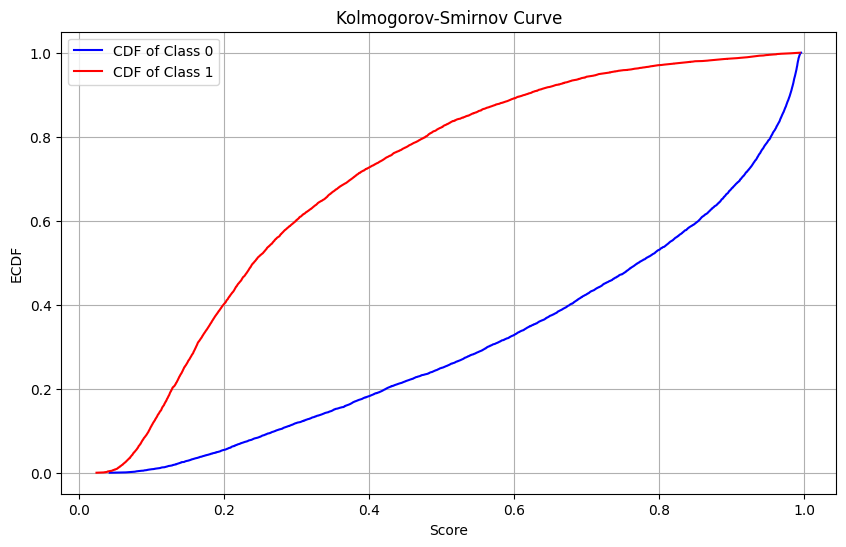

In [25]:
sample1_sorted = np.sort(score2[score2["target"] == 0]["score"])
sample2_sorted = np.sort(score2[score2["target"] == 1]["score"])

# Calculate the Empirical Cumulative Distribution Functions (ECDFs)
ecdf1 = np.arange(1, len(sample1_sorted) + 1) / len(sample1_sorted)
ecdf2 = np.arange(1, len(sample2_sorted) + 1) / len(sample2_sorted)


# Plotting the KS curve
plt.figure(figsize=(10, 6))
plt.plot(sample1_sorted, ecdf1, label='CDF of Class 0', color='blue')
plt.plot(sample2_sorted, ecdf2, label='CDF of Class 1', color='red')
plt.title('Kolmogorov-Smirnov Curve')
plt.xlabel('Score')
plt.ylabel('ECDF')
plt.legend()
plt.grid(True)
plt.show()

## PSI
Descripción: el Population Stability Index, es el mismo estadístico que CSI, aquí nos ayuda a observar si el score de entrenamiento es estable respecto al score de test

In [26]:
psi2=psi(score["score"],score2["score"])
display(Latex(fr"$PSI = {round(psi2*100,2)}\% $"))


<IPython.core.display.Latex object>

## Information Value
Descripción: Al igual que con las características, se aplica el IV sobre el score y la target real para medir predictibilidad

In [27]:
iv,woe=iv_and_woe(score["score"],score["target"])
iv=iv["IV"]
display(Latex(fr"$IV \ Trainning = {round(iv*100,2)}\% $"))

<IPython.core.display.Latex object>

In [28]:
iv,woe=iv_and_woe(score2["score"],score2["target"])
iv=iv["IV"]
display(Latex(fr"$IV \ Test= {round(iv*100,2)}\% $"))


<IPython.core.display.Latex object>

# AUC/GINI

Descripción, al igual que el IV y KS, es un estadísitco que nos permite medir el performance del modelo

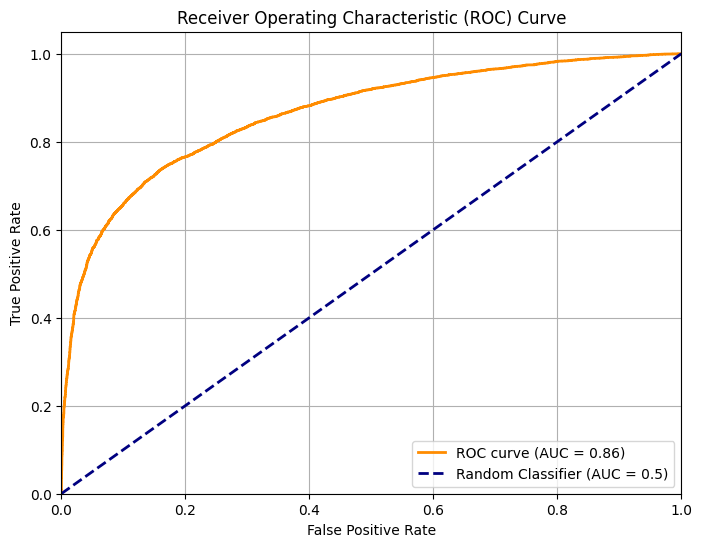

In [29]:

from sklearn import metrics
fp,tp,th = metrics.roc_curve(score2["target"],score2["score"])
roc_auc = metrics.auc(tp, fp)
plt.figure(figsize=(8, 6))
plt.plot(tp, fp, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

